# Preprocessing dan Ekstraksi Fitur oleh data CO 

**Persiapan Pengambilan Data CO**

Tahap awal adalah memasang library `openeo`. Library ini diperlukan agar notebook dapat berkomunikasi dengan layanan openEO yang digunakan untuk mengakses data Sentinel-5P.


In [ ]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Setelah library berhasil di-install, sekarang kita import `openeo`.

In [ ]:
import openeo

Perintah `import openeo` digunakan untuk memanggil library openEO yang sudah di-install, sehingga fungsi-fungsi openEO dapat digunakan pada kode Python selanjutnya.

Setelah library di-import, sekarang kita memasang koneksi ke server Copernicus Data Space.

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=CMDF-RAWN 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Jika muncul link autentikasi, buka link tersebut, login menggunakan akun Copernicus Data Space, lalu tekan Allow/Authorize. Setelah muncul pesan bahwa autentikasi berhasil, proses dapat dilanjutkan.

**Menentukan Geografis Kecamatan Kalianget**

In [ ]:
aoi = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [113.9513673, -7.0460006],
                        [113.946438, -7.0564837],
                        [113.9372051, -7.0622299],
                        [113.9028907, -7.0762189],
                        [113.873057, -7.0701868],
                        [113.8523076, -7.0613923],
                        [113.8864566, -7.0268656],
                        [113.9009699, -7.0291957],
                        [113.9167638, -7.0281366],
                        [113.9513673, -7.0460006]
                    ]
                ]
            }
        }
    ]
}

print("GeoJSON Kecamatan Kalianget siap digunakan.")

GeoJSON Kecamatan Kalianget siap digunakan.


Untuk membatasi pencarian data dari server, digunakan bounding box yang berasal dari koordinat terluar GeoJSON. Bounding box ini bukan pengganti GeoJSON. Polygon GeoJSON tetap digunakan pada `aggregate_spatial()`.

In [ ]:
spatial_extent = {
    "west": 113.8523076,
    "south": -7.0762189,
    "east": 113.9513673,
    "north": -7.0268656
}

print(spatial_extent)

{'west': 113.8523076, 'south': -7.0762189, 'east': 113.9513673, 'north': -7.0268656}


**Mengambil Data CO Sentinel-5P**

In [ ]:
s5CO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent=spatial_extent,
    bands=["CO"],
)

print("Data CO berhasil dipanggil.")

Data CO berhasil dipanggil.


**Membuat Data Harian**

In [ ]:
s5p_CO_daily = s5CO.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

print("Agregasi harian CO selesai.")

Agregasi harian CO selesai.


**Agregasi Berdasarkan Geografis Kecamatan Kalianget**

In [ ]:
s5p_CO_aoi = s5p_CO_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

print("Agregasi spasial Kecamatan Kalianget selesai.")

Agregasi spasial Kecamatan Kalianget selesai.


**Menjalankan Proses dan Menyimpan NetCDF**

In [ ]:
job_CO = s5p_CO_aoi.execute_batch(
    title="CO Kecamatan Kalianget 2025-2026",
    outputfile="CO_Kalianget_2025_2026.nc"
)

print("Job CO selesai dijalankan.")

0:00:00 Job 'j-260918055205468abb0765c9cb39eda8': send 'start'
0:00:03 Job 'j-260918055205468abb0765c9cb39eda8': queued (progress 0%)
0:00:08 Job 'j-260918055205468abb0765c9cb39eda8': queued (progress 0%)
0:00:15 Job 'j-260918055205468abb0765c9cb39eda8': queued (progress 0%)
0:00:23 Job 'j-260918055205468abb0765c9cb39eda8': queued (progress 0%)
0:00:33 Job 'j-260918055205468abb0765c9cb39eda8': queued (progress 0%)
0:00:45 Job 'j-260918055205468abb0765c9cb39eda8': queued (progress 0%)
0:01:01 Job 'j-260918055205468abb0765c9cb39eda8': queued (progress 0%)
0:01:20 Job 'j-260918055205468abb0765c9cb39eda8': running (progress N/A)
0:01:44 Job 'j-260918055205468abb0765c9cb39eda8': running (progress N/A)
0:02:14 Job 'j-260918055205468abb0765c9cb39eda8': running (progress N/A)
0:02:52 Job 'j-260918055205468abb0765c9cb39eda8': running (progress N/A)
0:03:39 Job 'j-260918055205468abb0765c9cb39eda8': finished (progress 100%)
Job CO selesai dijalankan.


**Membaca File NetCDF**

In [ ]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.6 MB/s eta 0:00:00


Library `netCDF4`, `numpy`, dan `pandas` kemudian di-import untuk membaca data dan mengubahnya menjadi DataFrame.

In [ ]:
import netCDF4
import numpy as np
import pandas as pd

In [ ]:
dsCO = netCDF4.Dataset("CO_Kalianget_2025_2026.nc")

print("File NetCDF CO berhasil dibuka.")

File NetCDF CO berhasil dibuka.


**Mengubah Data NetCDF Menjadi DataFrame dan di simpan dalam bentuk CSV**

In [ ]:
from google.colab import files

nama_file = "CO_Kalianget_2025_2026.csv"

df.to_csv(nama_file, index=False)

print("File CSV berhasil dibuat:")

print(nama_file)

print("\nJumlah baris :", len(df))

print("Jumlah kolom:", len(df.columns))

print("\n5 data pertama:")

display(df.head())

files.download(nama_file)

File CSV berhasil dibuat:
CO_Kalianget_2025_2026.csv

Jumlah baris : 200
Jumlah kolom: 2

5 data pertama:


,date,CO
0,2025-08-31,0.027079
1,2025-09-01,0.024383
2,2025-09-02,0.024593
3,2025-09-03,0.024952
4,2025-09-04,0.027547


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Pembersihan Data**

In [ ]:
print("Jumlah data:", len(df))
print("Missing value CO:", df["CO"].isna().sum())

display(df["CO"].describe())

Jumlah data: 200
Missing value CO: 0


,CO
count,200.000000
mean,0.027562
std,0.003405
min,0.018802
25%,0.025330
50%,0.027023
75%,0.029673
max,0.037928


 **Visualisasi Data Sebelum Cleaning**

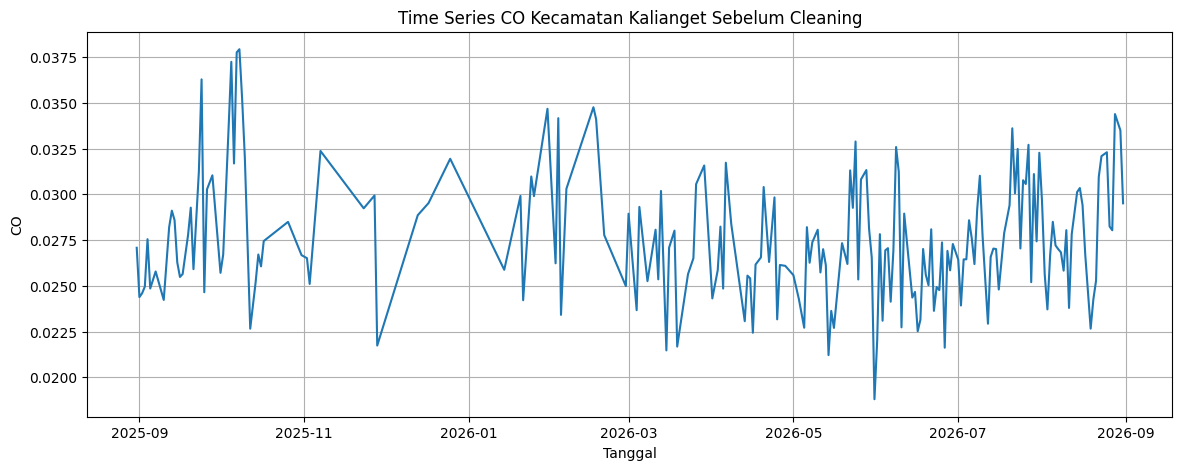

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["CO"])
plt.title("Time Series CO Kecamatan Kalianget Sebelum Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("CO")
plt.grid(True)
plt.show()

**Deteksi Outlier Menggunakan IQR**

Metode yang digunakan untuk mendeteksi outlier adalah Interquartile Range (IQR).

Rumus:

$$
IQR = Q3 - Q1
$$

Batas bawah:

$$
Q1 - 1.5(IQR)
$$

Batas atas:

$$
Q3 + 1.5(IQR)
$$

Nilai yang berada di luar batas tersebut dianggap sebagai outlier.

In [ ]:
Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df["CO"] < lower_bound) |
    (df["CO"] > upper_bound)
)

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Batas bawah =", lower_bound)
print("Batas atas =", upper_bound)
print("Jumlah outlier =", outlier_mask.sum())

display(df.loc[outlier_mask, ["date", "CO"]])

Q1 = 0.025329699274152448
Q3 = 0.02967258612625295
IQR = 0.004342886852100502
Batas bawah = 0.018815368996001697
Batas atas = 0.036186916404403704
Jumlah outlier = 5


,date,CO
18,2025-09-24,0.036281
25,2025-10-05,0.037240
27,2025-10-07,0.037758
28,2025-10-08,0.037928
117,2026-05-31,0.018802


**Menangani Outlier**

Outlier tidak langsung dihapus karena data ini merupakan time series. Nilai outlier diubah menjadi `NaN`, kemudian akan diisi menggunakan interpolasi berdasarkan waktu.

In [ ]:
df_clean = df.copy()

df_clean.loc[outlier_mask, "CO"] = np.nan

print("Jumlah missing setelah outlier ditandai:",
      df_clean["CO"].isna().sum())

Jumlah missing setelah outlier ditandai: 5


**Imputasi Missing Value**

In [ ]:
df_clean = (
    df_clean
    .set_index("date")
    .interpolate(method="time")
    .ffill()
    .bfill()
    .reset_index()
)

print("Jumlah missing setelah imputasi:",
      df_clean["CO"].isna().sum())

Jumlah missing setelah imputasi: 0


**Pemeriksaan Setelah Cleaning**

In [ ]:
Q1_final = df_clean["CO"].quantile(0.25)
Q3_final = df_clean["CO"].quantile(0.75)
IQR_final = Q3_final - Q1_final

lower_final = Q1_final - 1.5 * IQR_final
upper_final = Q3_final + 1.5 * IQR_final

final_outlier_mask = (
    (df_clean["CO"] < lower_final) |
    (df_clean["CO"] > upper_final)
)

jumlah_missing_final = df_clean["CO"].isna().sum()
jumlah_outlier_final = final_outlier_mask.sum()

print("==============================================")
print("HASIL PEMERIKSAAN DATA SETELAH CLEANING")
print("==============================================")
print("Missing value :", jumlah_missing_final)
print("Outlier       :", jumlah_outlier_final)

if jumlah_missing_final == 0 and jumlah_outlier_final == 0:
    print("Data sudah bersih dan siap untuk ekstraksi TSFEL.")
else:
    print("Masih terdapat data yang perlu diperiksa.")

HASIL PEMERIKSAAN DATA SETELAH CLEANING
Missing value : 0
Outlier       : 0
Data sudah bersih dan siap untuk ekstraksi TSFEL.


**Visualisasi Data Setelah Cleaning**

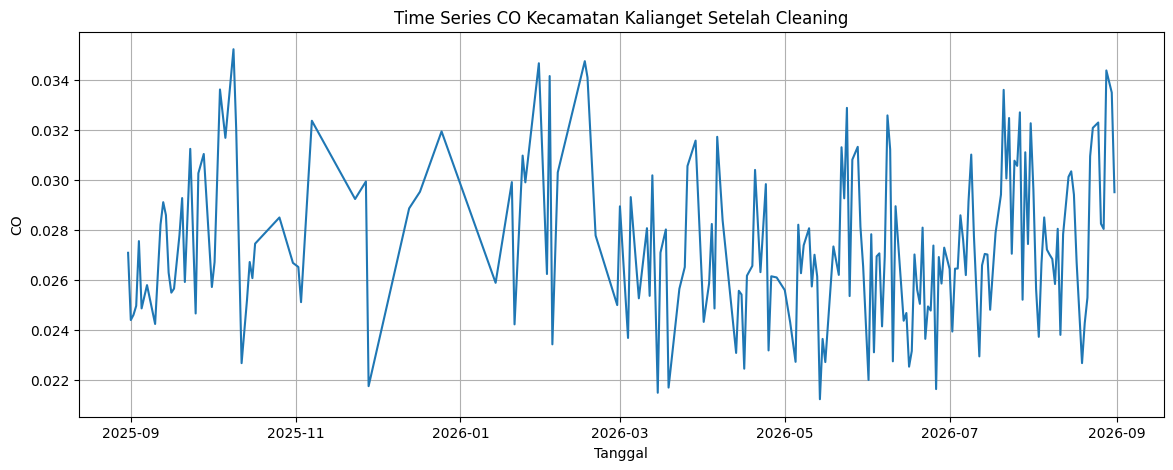

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df_clean["date"], df_clean["CO"])
plt.title("Time Series CO Kecamatan Kalianget Setelah Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("CO")
plt.grid(True)
plt.show()

In [ ]:
from google.colab import files

nama_file = "CO_Kalianget_clean.csv"

df_clean.to_csv(
    nama_file,
    index=False,
    encoding="utf-8-sig"
)

print("Data bersih disimpan sebagai:", nama_file)

files.download(nama_file)

Data bersih disimpan sebagai: CO_Kalianget_clean.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Ekstraksi Fitur Menggunakan TSFEL**

In [ ]:
pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('CO_Kalianget_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'CO'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Kalianget_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk CO: 68


**Pemeriksaan Hasil Ekstraksi**

In [ ]:
FINAL_CSV = "CO_Kalianget_TSFEL.csv"

check_csv = pd.read_csv(FINAL_CSV)

print("File          :", FINAL_CSV)
print("Shape         :", check_csv.shape)
print("Kolom pertama :", check_csv.columns[0])
print("Kolom terakhir:", check_csv.columns[-1])

if check_csv.shape != (1, 68):
    raise ValueError(f"Shape salah: {check_csv.shape}; seharusnya (1, 68). Periksa kembali Bagian 4.")

print("\nFile final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.")

files.download(FINAL_CSV)

print("Unduhan dimulai:", FINAL_CSV, "-- JANGAN diubah/di-edit setelah ini.")

File          : CO_Kalianget_TSFEL.csv
Shape         : (1, 68)
Kolom pertama : abs_energy
Kolom terakhir: zero_cross

File final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: CO_Kalianget_TSFEL.csv -- JANGAN diubah/di-edit setelah ini.
